In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# DATASET1 (Healthcare attrition)

In [2]:
df=pd.read_csv("EmployeeArt/dataset3_manufacture.csv")
# df=df.drop(columns=["EmployeeID"])
# df["Emp_ID"].value_counts()

In [3]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [8]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

In [22]:
# df=df.drop(columns=[""]
df["Work_accident"].value_counts()
df["promotion_last_5years"].value_counts()
df["left"].value_counts()
df["salary"]
# df["satisfaction_level"]
# df["satisfaction_level"]

0           low
1        medium
2        medium
3           low
4           low
          ...  
14994       low
14995       low
14996       low
14997       low
14998       low
Name: salary, Length: 14999, dtype: object

In [23]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

## EDA


In [24]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

In [25]:
df.columns.shape

(10,)

In [26]:
col = df["left"]
df = df.drop("left", axis=1)
df["left"] = col

In [27]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'Department', 'salary', 'left'],
      dtype='object')

In [32]:

# CategoricalCols=np.zeros(len(df.columns))
# NumericCols=np.zeros(len(df.columns))

# CategoricalColsIndex=[] # index from 0
# NumericColsIndex=[]
# for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
#     if dtype=="object":
#         CategoricalCols[i]=1
#         CategoricalColsIndex.append(i)
#         df[col] = df[col].astype('category')
#     else:
#         NumericCols[i]=1
#         NumericColsIndex.append(i)

df["Work_accident"]=df["Work_accident"].astype('category')
df["promotion_last_5years"]=df["promotion_last_5years"].astype('category')
df["left"]=df["left"].astype('category')
df["salary"]=df["salary"].astype('category')
df["Department"]=df["Department"].astype('category')



In [33]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'Department', 'salary', 'left'],
      dtype='object')

In [34]:
df.dtypes

satisfaction_level        float64
last_evaluation           float64
number_project              int64
average_montly_hours        int64
time_spend_company          int64
Work_accident            category
promotion_last_5years    category
Department               category
salary                   category
left                     category
dtype: object

In [35]:
df.shape

(14999, 10)

In [ ]:
# NumericCols
# print(NumericColsIndex)

In [37]:
df.left

0        1
1        1
2        1
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: left, Length: 14999, dtype: category
Categories (2, int64): [0, 1]

In [38]:
# df.columns
corrmatrix=df.corr(numeric_only=True)
corrmatrix.head(23)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000


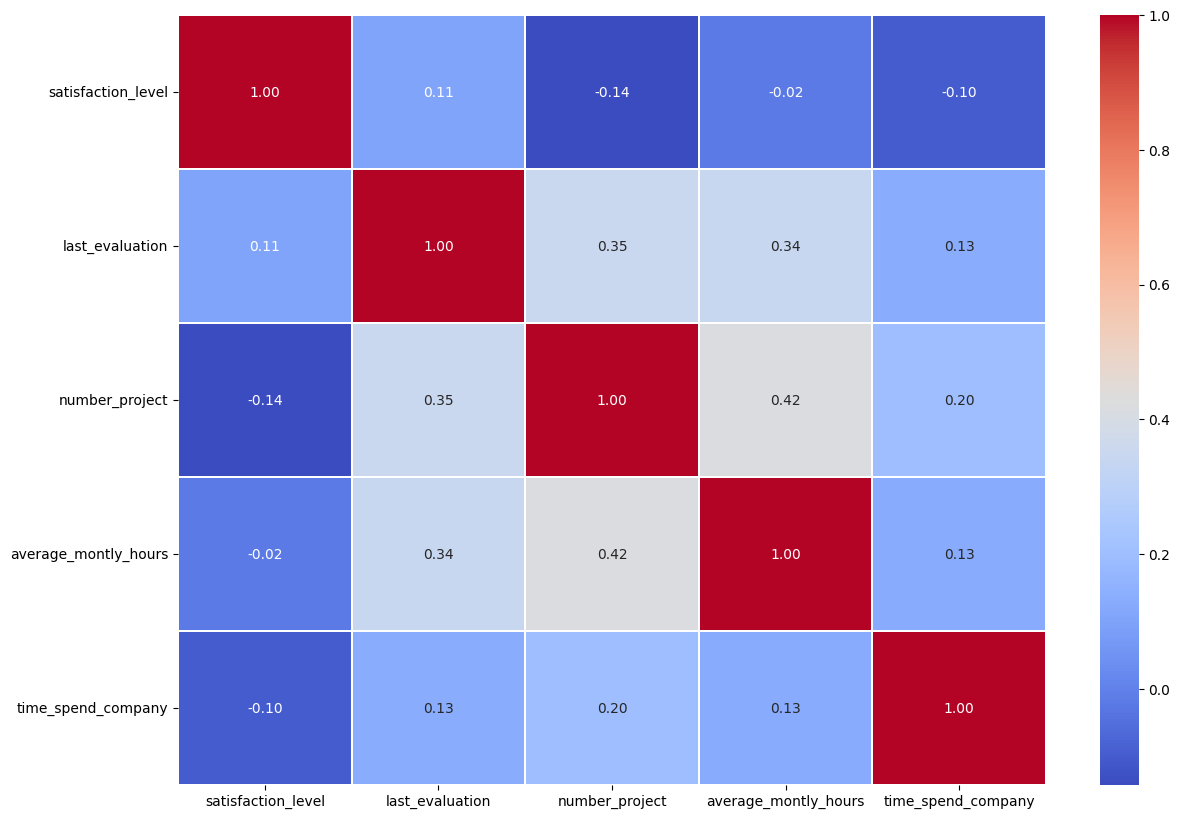

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))  
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.1)
plt.show()


In [ ]:
# high corellation between performance rating and salary hike
# job level nad years of working

In [40]:
categorical_df = df.select_dtypes(include=['category'])
categorical_df

,Work_accident,promotion_last_5years,Department,salary,left
0,0,0,sales,low,1
1,0,0,sales,medium,1
2,0,0,sales,medium,1
3,0,0,sales,low,1
4,0,0,sales,low,1
...,...,...,...,...,...
14994,0,0,support,low,1
14995,0,0,support,low,1
14996,0,0,support,low,1
14997,0,0,support,low,1


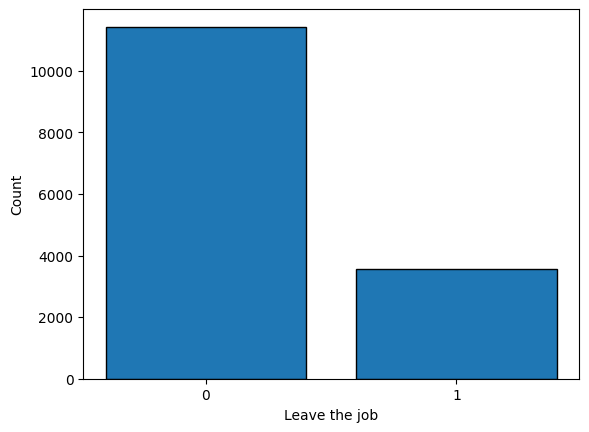

In [41]:
counts = df["left"].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xticks(counts.index) # imp
plt.xlabel("Leave the job")
plt.ylabel("Count")
plt.show()

In [44]:
non_categorical_cols = df.select_dtypes(include=['number']).columns

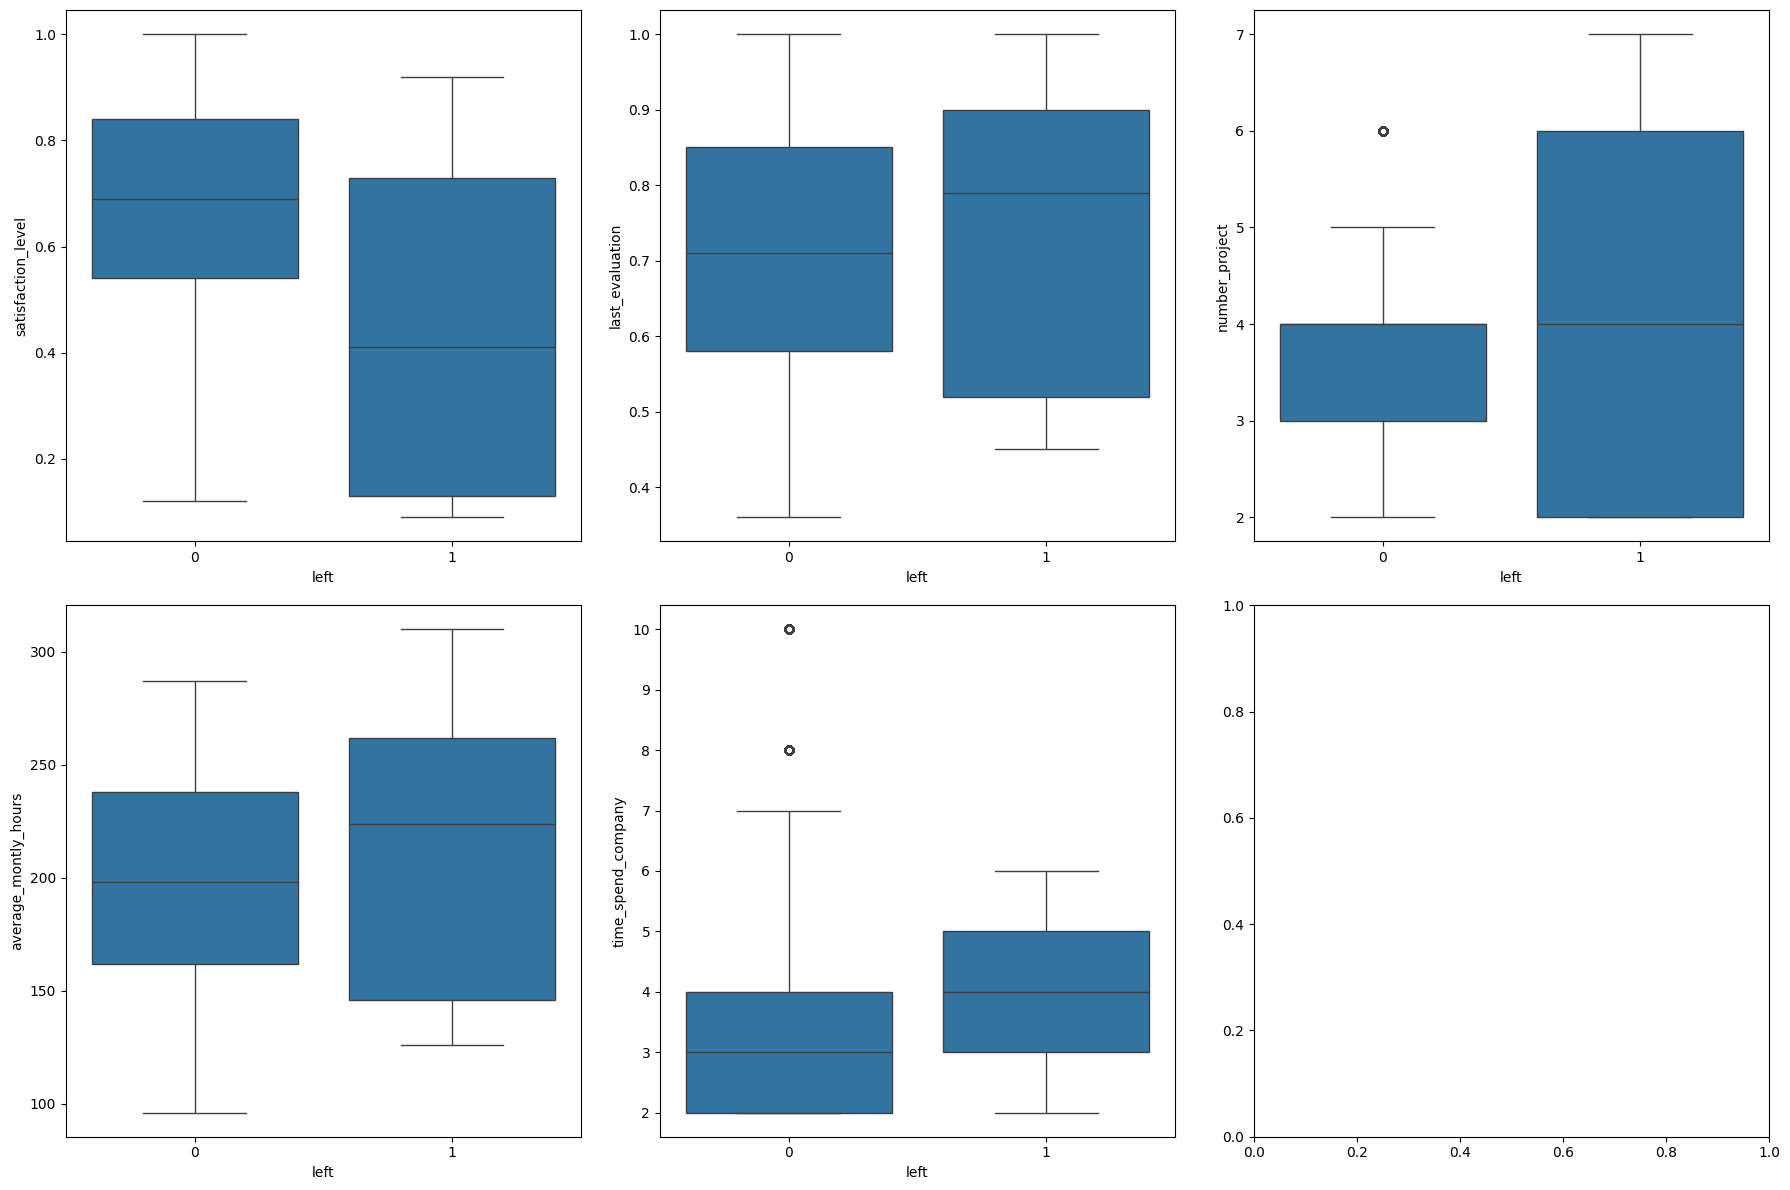

In [45]:
import math

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0
for i in df.columns:
    if df[i].dtype!="category":
        sns.boxplot(ax=axes[row,col],x=df['left'],y=df[i])
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()

In [46]:
df.dtypes

satisfaction_level        float64
last_evaluation           float64
number_project              int64
average_montly_hours        int64
time_spend_company          int64
Work_accident            category
promotion_last_5years    category
Department               category
salary                   category
left                     category
dtype: object

In [ ]:
# df[""].value_counts()

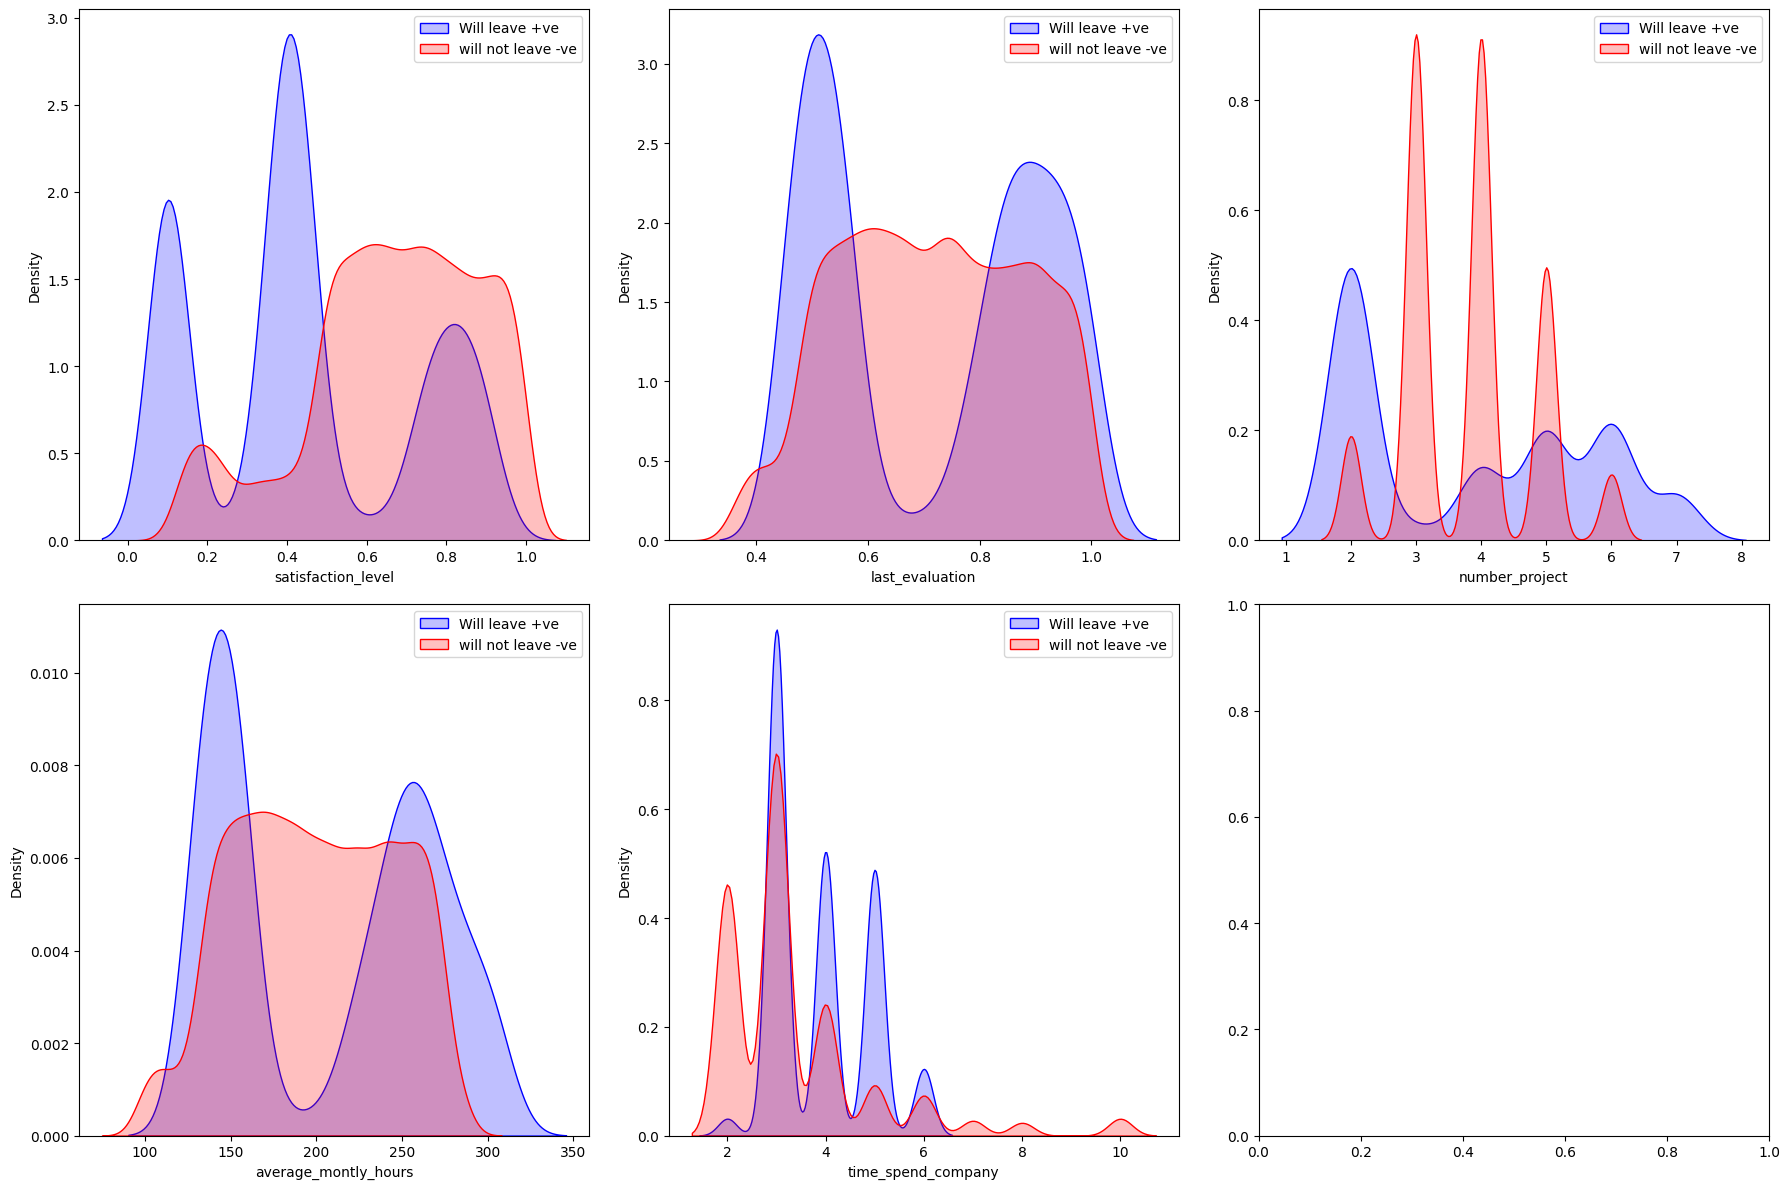

In [48]:

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if df[i].dtype!="category":
        
        sns.kdeplot(
            df[df["left"]==1][i],
            color='blue', label='Will leave +ve',
            ax=axes[row,col],
            fill=True
            )
        
        sns.kdeplot(
            df[df["left"]==0][i],
            color='red', 
            label='will not leave -ve',
            ax=axes[row,col],
            fill=True
            )
        
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()





KeyError: 'LeftCompany'

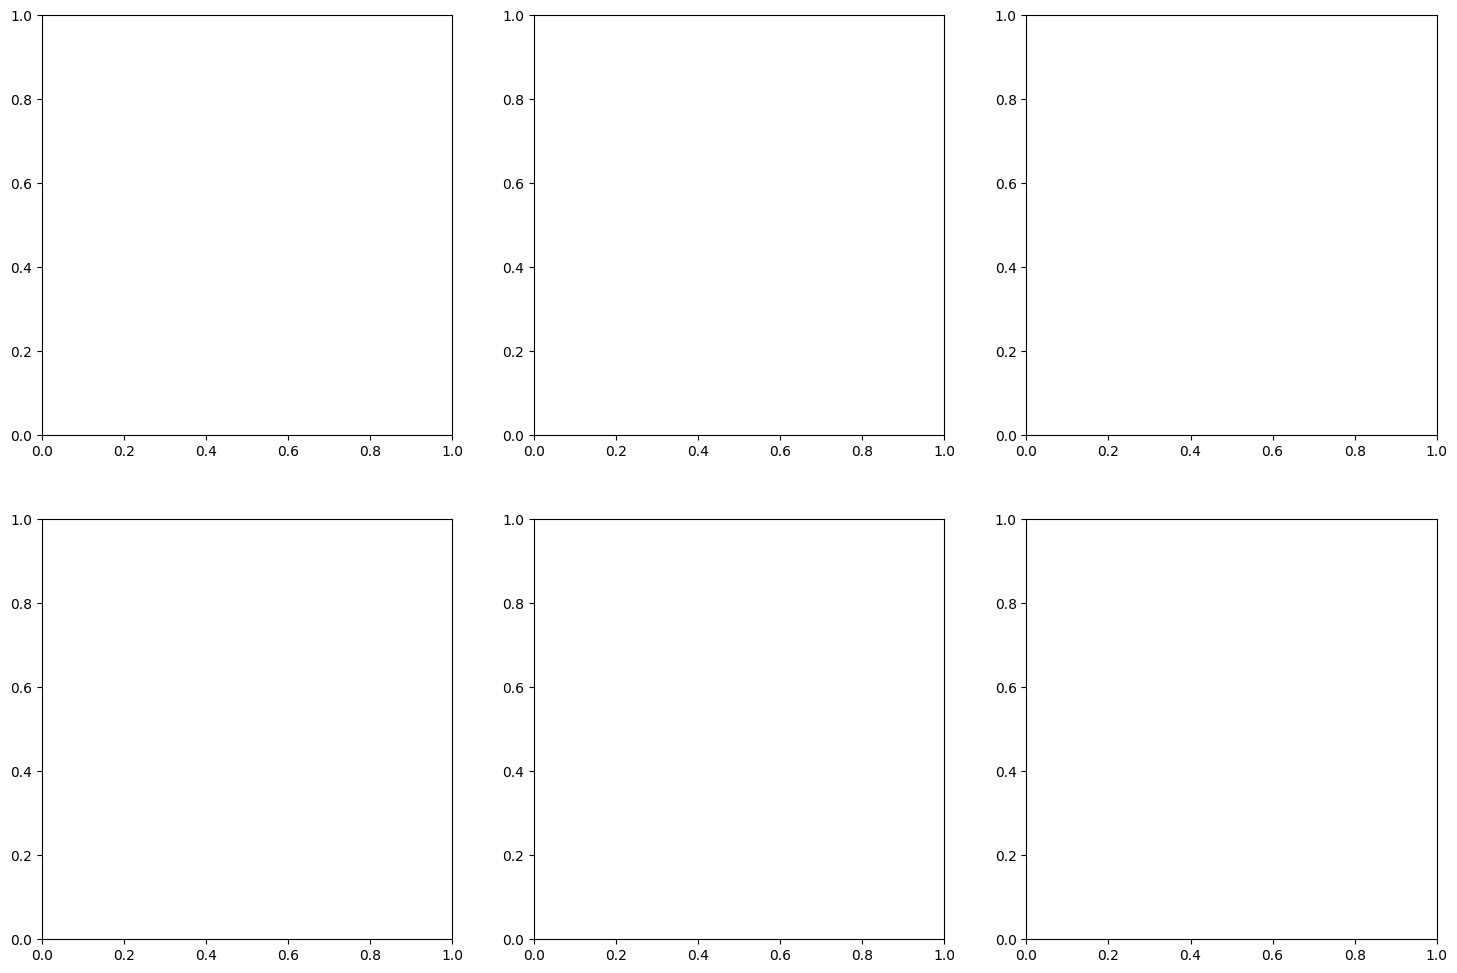

In [ ]:
count=0
collist=[]
for i in df.columns:
    if len(df[i].value_counts())<=7:
        count+=1
        collist.append(i)
total_plots = count-1 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if i != "LeftCompany" and len(df[i].value_counts())<=7:
        crosstb = pd.crosstab(df[i], df["left"])
        crosstb.plot(kind="bar",ax=axes[row,col])
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols


plt.tight_layout(w_pad=2)
plt.show()